In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data = fetch_openml(data_id=44225, as_frame=True)

X = data.data
y = data.target

df = pd.concat([X, y], axis=1)

print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(y.value_counts())


Dataset Shape: (10362, 15)

Class Distribution:
MEMBERSHIP_STATUS
INFORCE      7219
CANCELLED    3143
Name: count, dtype: int64


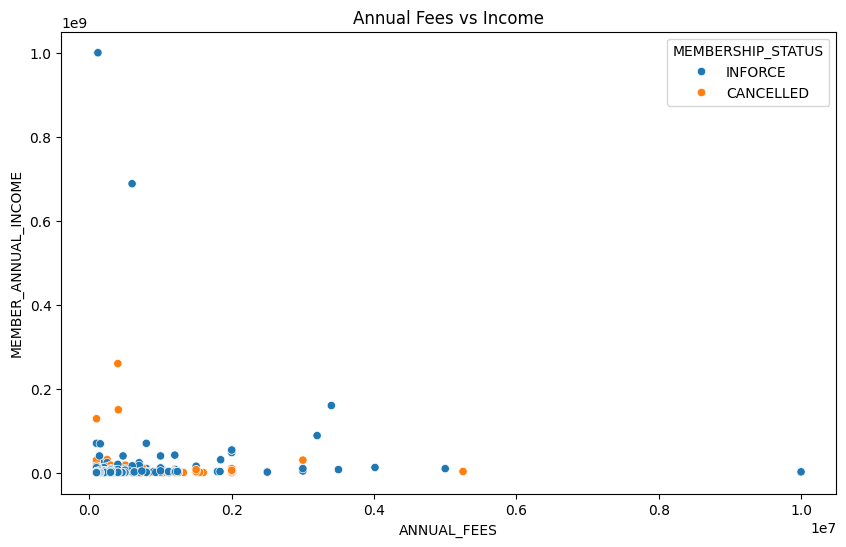

In [3]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="ANNUAL_FEES",
    y="MEMBER_ANNUAL_INCOME",
    hue="MEMBERSHIP_STATUS"
)
plt.title("Annual Fees vs Income")
plt.show()


In [4]:
# Drop date columns
X = X.drop(columns=[col for col in X.columns if "DATE" in col])

# Drop ID columns (improves accuracy)
X = X.drop(columns=["MEMBERSHIP_NUMBER", "AGENT_CODE"])

# Fill categorical missing values
cat_cols = X.select_dtypes(include="object").columns
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Fill numeric missing values
num_cols = X.select_dtypes(include=np.number).columns
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# One hot encoding
X = pd.get_dummies(X)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,     # improved
    max_depth=3,          # lab requirement
    bootstrap=True,
    oob_score=True,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

print("\nOOB Score:", rf.oob_score_)


OOB Score: 0.5411991796356618


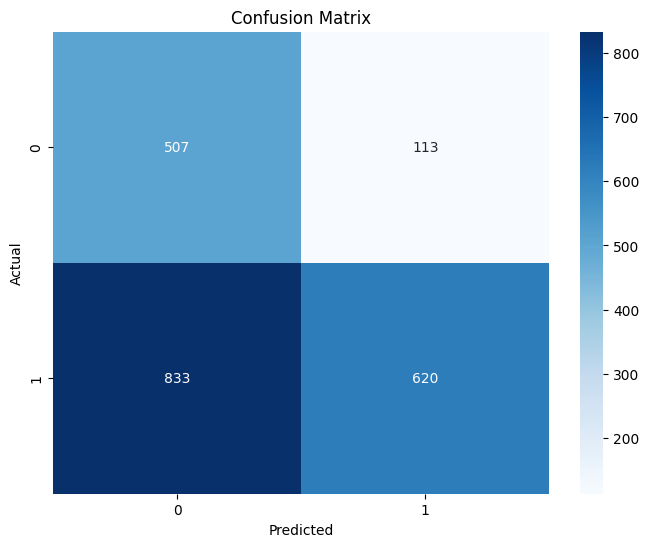


Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.82      0.52       620
           1       0.85      0.43      0.57      1453

    accuracy                           0.54      2073
   macro avg       0.61      0.62      0.54      2073
weighted avg       0.71      0.54      0.55      2073



In [6]:
y_pred = rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

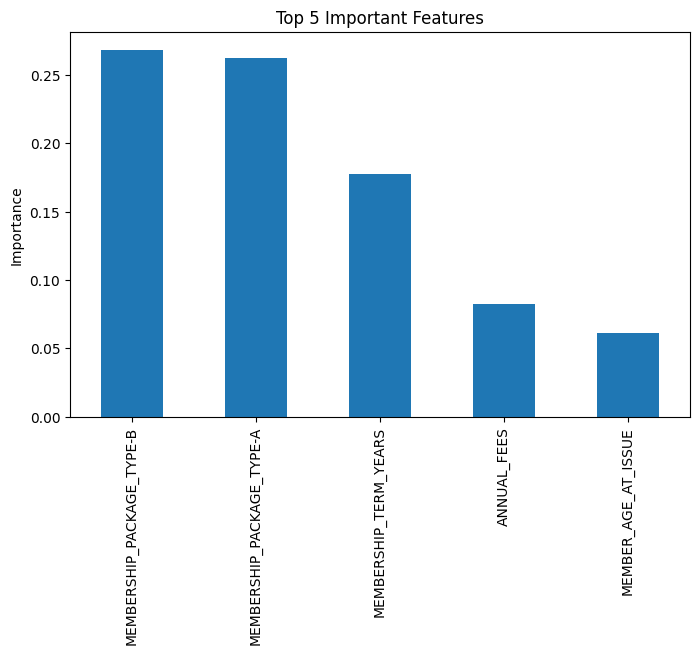

In [7]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
top5 = feat_imp.sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
top5.plot(kind='bar')
plt.title("Top 5 Important Features")
plt.ylabel("Importance")
plt.show()